In [5]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats

from scipy.stats import shapiro, levene

import scikit_posthocs as sp

from scipy.stats import kruskal

from sklearn.decomposition import PCA

import numpy as np

import pickle

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7607.88it/s]


In [50]:

# carico i dataset
synonym_df = pd.read_csv("synonym_pairs_final.csv")
antonym_df = pd.read_csv("antonym_pairs_final.csv")
random_df = pd.read_csv("random_pairs_final.csv")


#codice da eseguire per avere gli embedding modello contestuale

import pickle

with open("embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)

In [7]:
#Estrazione delle PCA (50,10,2 D)
#converto dizionario di embedding in una matrice Numpy
#creo una lista contenente le chiavi del dizionario
words = list(embeddings.keys())
#creo la matrice degli embedding vstack impila vettori e adatto tensor pytorch a numpy
embedding_matrix = np.vstack([
    embeddings[word].numpy()
    for word in words
])

print(embedding_matrix.shape)

(638, 384)


In [8]:
#PCA 50 D
pca_50 = PCA(n_components=50)
pca_50_embedding = pca_50.fit_transform(embedding_matrix)
print("Dimensione della matrice dopo PCA 50 D:", pca_50_embedding.shape)
print("Varianza spiegata totale:", pca_50.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 50 D: (638, 50)
Varianza spiegata totale: 0.55772096


In [9]:
#PCA 10 D
pca_10 = PCA(n_components=10)
pca_10_embedding = pca_10.fit_transform(embedding_matrix)
print("Dimensione della matrice dopo PCA 10 D:", pca_10_embedding.shape)
print("Varianza spiegata totale:", pca_10.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 10 D: (638, 10)
Varianza spiegata totale: 0.19610973


In [10]:
#PCA 2 D
pca_2 = PCA(n_components=2)
pca_2_embedding = pca_2.fit_transform(embedding_matrix)
print("Dimensione della matrice dopo PCA 2 D:", pca_2_embedding.shape)
print("Varianza spiegata totale:", pca_2.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 2 D: (638, 2)
Varianza spiegata totale: 0.05459054


In [11]:
#riassunto:
print("Varianza spiegata totale di PCA 50 D:", pca_50.explained_variance_ratio_.sum())
print("Varianza spiegata totale di PCA 10 D:", pca_10.explained_variance_ratio_.sum())
print("Varianza spiegata totale di PCA 2 D:", pca_2.explained_variance_ratio_.sum())

Varianza spiegata totale di PCA 50 D: 0.55772096
Varianza spiegata totale di PCA 10 D: 0.19610973
Varianza spiegata totale di PCA 2 D: 0.05459054


In [12]:
#ricreo dizionari di embedding

diz_embeddings_pca_50 = {
    word: pca_50_embedding [i]
    for i, word in enumerate(words)
}

diz_embeddings_pca_10 = {
    word: pca_10_embedding [i]
    for i, word in enumerate(words)
}

diz_embeddings_pca_2 = {
    word: pca_2_embedding [i]
    for i, word in enumerate(words)
}

In [46]:
word = words[0]

print(word)

print("50D:", diz_embeddings_pca_50[word][:5])
print("10D:", diz_embeddings_pca_10[word][:5])
print("2D:", diz_embeddings_pca_2[word])
print(len(diz_embeddings_pca_50[word]))
print(len(diz_embeddings_pca_10[word]))
print(len(diz_embeddings_pca_2[word]))

faithful
50D: [-0.0083705   0.13184433  0.04915611  0.09495291  0.10969767]
10D: [-0.00866335  0.13255216  0.05164926  0.10095201  0.12168581]
2D: [-0.00924419  0.1296743 ]
50
10
2


In [47]:
#rifaccio primo esperimento per le tre distribuzioni:


#funzione per la cosine similarity

def add_cosine_similarity(df, col1, col2, diz_embedding ):
    #in input entrano: il database delle coppie, la colonna della parola e la colonna della parola associata, il dizionario della PCA
    #si crea una lista  per i risultati della cosine similarity
    #si calcola la cosine similarity usando gli embedding già calcolati
    #si crea una colonna nel dataset di partenza con i risultati della cosine similarity
    
    similarities = []

    for w1, w2 in zip(df[col1], df[col2]):

        emb1 = diz_embedding[w1]
        emb2 = diz_embedding[w2]

        similarity = cos_sim(
            emb1,
            emb2
        ).item()

        similarities.append(similarity)


    df["cosine_similarity"] = similarities

    return df

In [48]:
#funzione per sinonimi

syn_df_50D = add_cosine_similarity(
    synonym_df.copy(),
    "word",
    "synonym",
    diz_embeddings_pca_50
)

syn_df_10D = add_cosine_similarity(
    synonym_df.copy(),
    "word",
    "synonym",
    diz_embeddings_pca_10
)

syn_df_2D = add_cosine_similarity(
    synonym_df.copy(),
    "word",
    "synonym",
    diz_embeddings_pca_2
)

print("Sinonimi PCA 50 D:\n" ,syn_df_50D.head() )
print("\n")
print("Sinonimi PCA 10 D:\n", syn_df_10D.head())
print("\n")
print("Sinonimi PCA 2 D:\n",syn_df_2D.head())

Sinonimi PCA 50 D:
        word      synonym relation  cosine_similarity
0  revolved      rotated  synonym           0.423961
1   ghastly      macabre  synonym          -0.005871
2     dodgy        dicey  synonym           0.333170
3  biweekly  fortnightly  synonym           0.273903
4   pouring      gushing  synonym           0.570936


Sinonimi PCA 10 D:
        word      synonym relation  cosine_similarity
0  revolved      rotated  synonym           0.475690
1   ghastly      macabre  synonym           0.195614
2     dodgy        dicey  synonym           0.110656
3  biweekly  fortnightly  synonym           0.656051
4   pouring      gushing  synonym           0.571535


Sinonimi PCA 2 D:
        word      synonym relation  cosine_similarity
0  revolved      rotated  synonym           0.350186
1   ghastly      macabre  synonym          -0.806425
2     dodgy        dicey  synonym           0.153129
3  biweekly  fortnightly  synonym           0.963233
4   pouring      gushing  synonym   

In [51]:
#funzione per contrari
ant_df_50D = add_cosine_similarity(
    antonym_df.copy(),
    "word",
    "antonym",
    diz_embeddings_pca_50
)

ant_df_10D = add_cosine_similarity(
    antonym_df.copy(),
    "word",
    "antonym",
    diz_embeddings_pca_10
)

ant_df_2D = add_cosine_similarity(
    antonym_df.copy(),
    "word",
    "antonym",
    diz_embeddings_pca_2
)

print("Contrari PCA 50 D:\n" ,ant_df_50D.head() )
print("\n")
print("Contrari PCA 10 D:\n", ant_df_10D.head())
print("\n")
print("Contrari PCA 2 D:\n",ant_df_2D.head())

Contrari PCA 50 D:
           word        antonym relation  cosine_similarity
0    ascending     descending  antonym           0.875377
1  centralized  decentralized  antonym           0.709005
2   reasonable   unreasonable  antonym           0.709504
3       simple        complex  antonym           0.414643
4      legible      illegible  antonym           0.361101


Contrari PCA 10 D:
           word        antonym relation  cosine_similarity
0    ascending     descending  antonym           0.879746
1  centralized  decentralized  antonym           0.740664
2   reasonable   unreasonable  antonym           0.823503
3       simple        complex  antonym           0.666234
4      legible      illegible  antonym           0.670357


Contrari PCA 2 D:
           word        antonym relation  cosine_similarity
0    ascending     descending  antonym           0.996970
1  centralized  decentralized  antonym           0.656215
2   reasonable   unreasonable  antonym           0.892899
3       s

In [52]:
#Random
rand_df_50D = add_cosine_similarity(
    random_df.copy(),
    "word",
    "random",
    diz_embeddings_pca_50
)

rand_df_10D = add_cosine_similarity(
    random_df.copy(),
    "word",
    "random",
    diz_embeddings_pca_10
)

rand_df_2D = add_cosine_similarity(
    random_df.copy(),
    "word",
    "random",
    diz_embeddings_pca_2
)

print("Random PCA 50 D:\n" ,rand_df_50D.head())
print("\n")
print("Random PCA 10 D:\n" ,rand_df_10D.head())
print("\n")
print("Random PCA 2 D:\n" ,rand_df_2D.head())

Random PCA 50 D:
           word       random relation  cosine_similarity
0     plodding    bombastic   random          -0.008073
1  unpalatable  melancholic   random           0.162365
2     obliging     definite   random          -0.156356
3    punishing  recombinant   random          -0.020160
4      opposed        ionic   random           0.015166


Random PCA 10 D:
           word       random relation  cosine_similarity
0     plodding    bombastic   random           0.092156
1  unpalatable  melancholic   random           0.259108
2     obliging     definite   random          -0.083556
3    punishing  recombinant   random           0.016797
4      opposed        ionic   random          -0.133607


Random PCA 2 D:
           word       random relation  cosine_similarity
0     plodding    bombastic   random          -0.788891
1  unpalatable  melancholic   random           0.277437
2     obliging     definite   random          -0.464236
3    punishing  recombinant   random           

In [53]:
#salvo i risultati
syn_df_50D.to_csv(
    "results_synonyms_similarity_PCA50.csv",
    index=False
)

syn_df_10D.to_csv(
    "results_synonyms_similarity_PCA10.csv",
    index=False
)

syn_df_2D.to_csv(
    "results_synonyms_similarity_PCA2.csv",
    index=False
)

ant_df_50D.to_csv(
    "results_antonyms_similarity_PCA50.csv",
    index=False
)

ant_df_10D.to_csv(
    "results_antonyms_similarity_PCA10.csv",
    index=False
)

ant_df_2D.to_csv(
    "results_antonyms_similarity_PCA2.csv",
    index=False
)

rand_df_50D.to_csv(
    "results_random_similarity_PCA50.csv",
    index=False
)

rand_df_10D.to_csv(
    "results_random_similarity_PCA10.csv",
    index=False
)

rand_df_2D.to_csv(
    "results_random_similarity_PCA2.csv",
    index=False
)

In [54]:
#per caricare dataset con cosine similarity

syn_df_50D = pd.read_csv("results_synonyms_similarity_PCA50.csv")
syn_df_10D = pd.read_csv("results_synonyms_similarity_PCA10.csv")
syn_df_2D = pd.read_csv("results_synonyms_similarity_PCA2.csv")
ant_df_50D = pd.read_csv("results_antonyms_similarity_PCA50.csv")
ant_df_10D = pd.read_csv("results_antonyms_similarity_PCA10.csv")
ant_df_2D = pd.read_csv("results_antonyms_similarity_PCA2.csv")
rand_df_50D = pd.read_csv("results_random_similarity_PCA50.csv")
rand_df_10D = pd.read_csv("results_random_similarity_PCA10.csv")
rand_df_2D = pd.read_csv("results_random_similarity_PCA2.csv")

In [55]:
#Statistiche descrittive
#sinonimi
print("SINONIMI")
print("Sinonimi per embedding a 50 dimensioni:\n")
print(syn_df_50D["cosine_similarity"].describe().round(3))
print("Sinonimi per embedding a 10 dimensioni:\n")
print(syn_df_10D["cosine_similarity"].describe().round(3))
print("Sinonimi per embedding a 2 dimensioni:\n")
print(syn_df_2D["cosine_similarity"].describe().round(3))
print("\nCONTRARI")
print("Contrari per embedding a 50 dimensioni:\n")
print(ant_df_50D["cosine_similarity"].describe().round(3))
print("Contrari per embedding a 10 dimensioni:\n")
print(ant_df_10D["cosine_similarity"].describe().round(3))
print("Contrari per embedding a 2 dimensioni:\n")
print(ant_df_2D["cosine_similarity"].describe().round(3))
print("\nRANDOM")
print("Random per embedding a 50 dimensioni:\n")
print(rand_df_50D["cosine_similarity"].describe().round(3))
print("Random per embedding a 10 dimensioni:\n")
print(rand_df_10D["cosine_similarity"].describe().round(3))
print("Random per embedding a 2 dimensioni:\n")
print(rand_df_2D["cosine_similarity"].describe().round(3))

SINONIMI
Sinonimi per embedding a 50 dimensioni:

count    111.000
mean       0.336
std        0.259
min       -0.168
25%        0.126
50%        0.361
75%        0.551
max        0.842
Name: cosine_similarity, dtype: float64
Sinonimi per embedding a 10 dimensioni:

count    111.000
mean       0.430
std        0.347
min       -0.430
25%        0.181
50%        0.511
75%        0.713
max        0.936
Name: cosine_similarity, dtype: float64
Sinonimi per embedding a 2 dimensioni:

count    111.000
mean       0.373
std        0.701
min       -1.000
25%       -0.191
50%        0.722
75%        0.970
max        1.000
Name: cosine_similarity, dtype: float64

CONTRARI
Contrari per embedding a 50 dimensioni:

count    111.000
mean       0.467
std        0.274
min       -0.158
25%        0.276
50%        0.525
75%        0.689
max        0.905
Name: cosine_similarity, dtype: float64
Contrari per embedding a 10 dimensioni:

count    111.000
mean       0.481
std        0.347
min       -0.469
25%  

C:\Users\marco\AppData\Local\Temp\ipykernel_10304\3574747906.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


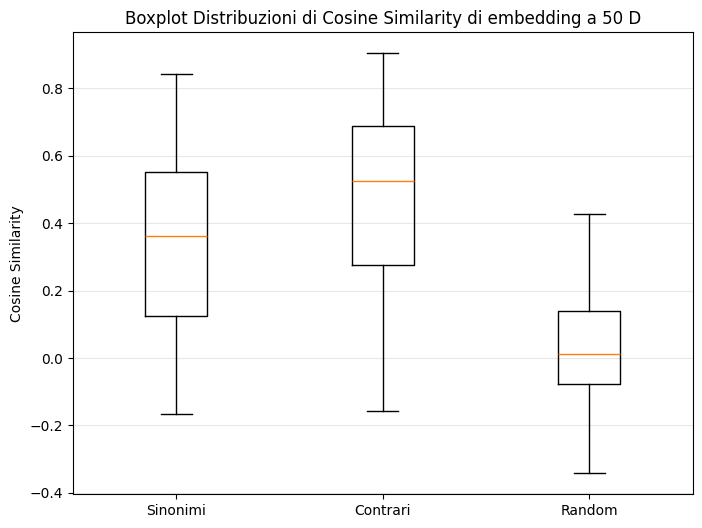

In [56]:
#BOX-Plot PCA 50 D:
#confronto tra le distribuzioni: box plot
plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        syn_df_50D["cosine_similarity"],
        ant_df_50D["cosine_similarity"],
        rand_df_50D["cosine_similarity"]
    ],
    labels=["Sinonimi", "Contrari", "Random"]
)

plt.ylabel("Cosine Similarity")
plt.title("Boxplot Distribuzioni di Cosine Similarity di embedding a 50 D")

plt.grid(axis="y", alpha=0.3)

#lo salvo
plt.savefig(
    "boxplot_cosine_similarity_50D.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\marco\AppData\Local\Temp\ipykernel_10304\3089064329.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


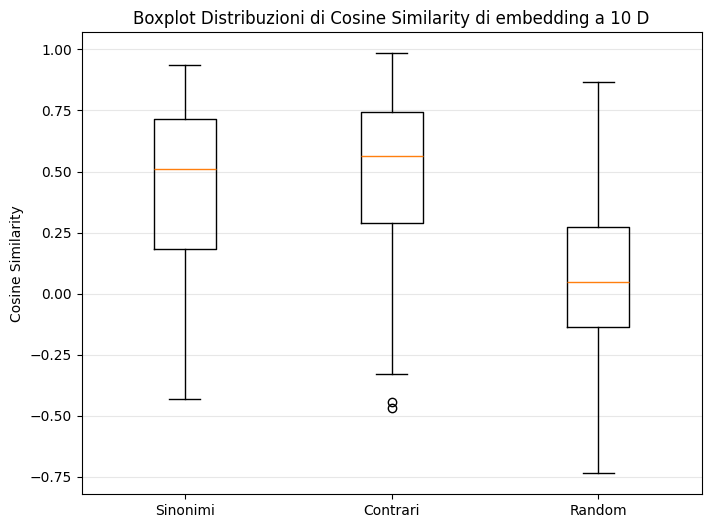

In [57]:
#BOX-Plot PCA 10 D:

plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        syn_df_10D["cosine_similarity"],
        ant_df_10D["cosine_similarity"],
        rand_df_10D["cosine_similarity"]
    ],
    labels=["Sinonimi", "Contrari", "Random"]
)

plt.ylabel("Cosine Similarity")
plt.title("Boxplot Distribuzioni di Cosine Similarity di embedding a 10 D")

plt.grid(axis="y", alpha=0.3)

#lo salvo
plt.savefig(
    "boxplot_cosine_similarity_10D.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\marco\AppData\Local\Temp\ipykernel_10304\1874310280.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


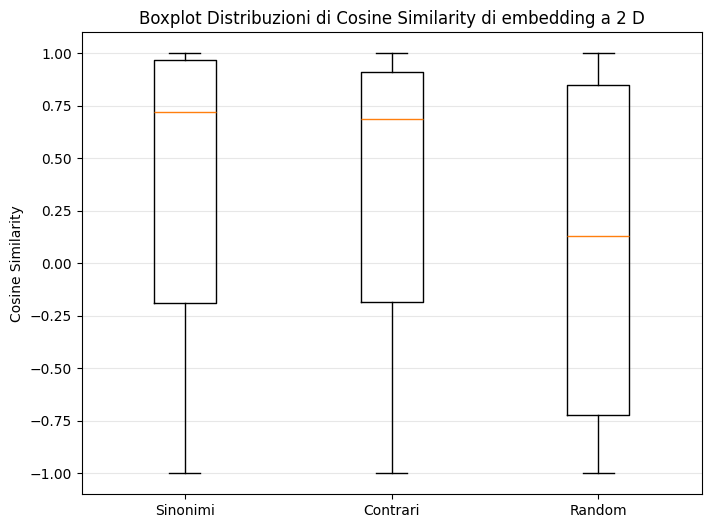

In [58]:
#BOX-Plot PCA 2 D:

plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        syn_df_2D["cosine_similarity"],
        ant_df_2D["cosine_similarity"],
        rand_df_2D["cosine_similarity"]
    ],
    labels=["Sinonimi", "Contrari", "Random"]
)

plt.ylabel("Cosine Similarity")
plt.title("Boxplot Distribuzioni di Cosine Similarity di embedding a 2 D")

plt.grid(axis="y", alpha=0.3)

#lo salvo
plt.savefig(
    "boxplot_cosine_similarity_2D.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
#Valutazione se usare Anova o meno 1:
#ci sono evidenze statistiche contro la normalità di distribuzione delle distanze?
#Shapiro-Wilk test


def Shapiro_test (syn_df, ant_df, rand_df):
    print("Shapiro-Wilk test\n")

    for nome, df in [
        ("Sinonimi", syn_df),
        ("Contrari", ant_df),
        ("Random", rand_df)
    ]:

        statistica, p_value = shapiro(df["cosine_similarity"])

        print(f"{nome}")
        print(f"W = {statistica:.4f}")
        print(f"p-value = {p_value:.4f}")

        if p_value > 0.05:
            print("→ La Distribuzione è compatibile con la distribuzione normale.\n")
        else:
            print("→la distribuzione non è compatibile con la distribuzione normale.\n")
            
    return statistica, p_value

#PCA

print("PCA 50\n")
Shapiro_50D = Shapiro_test(syn_df_50D, ant_df_50D, rand_df_50D)
print("\nPCA 10\n")
Shapiro_10D = Shapiro_test(syn_df_10D, ant_df_10D, rand_df_10D)
print("\nPCA 2\n")
Shapiro_2D = Shapiro_test(syn_df_2D, ant_df_2D, rand_df_2D)

PCA 50

Shapiro-Wilk test

Sinonimi
W = 0.9767
p-value = 0.0490
→la distribuzione non è compatibile con la distribuzione normale.

Contrari
W = 0.9629
p-value = 0.0035
→la distribuzione non è compatibile con la distribuzione normale.

Random
W = 0.9927
p-value = 0.8217
→ La Distribuzione è compatibile con la distribuzione normale.


PCA 10

Shapiro-Wilk test

Sinonimi
W = 0.9416
p-value = 0.0001
→la distribuzione non è compatibile con la distribuzione normale.

Contrari
W = 0.9240
p-value = 0.0000
→la distribuzione non è compatibile con la distribuzione normale.

Random
W = 0.9884
p-value = 0.4570
→ La Distribuzione è compatibile con la distribuzione normale.


PCA 2

Shapiro-Wilk test

Sinonimi
W = 0.8077
p-value = 0.0000
→la distribuzione non è compatibile con la distribuzione normale.

Contrari
W = 0.8187
p-value = 0.0000
→la distribuzione non è compatibile con la distribuzione normale.

Random
W = 0.8703
p-value = 0.0000
→la distribuzione non è compatibile con la distribuzione norm

In [ ]:
#Test Lavene sull'omogeneità delle varianze tra le 3 distribuzioni (già dal boxplot potevamo ipotizzare che non lo fossero)
def Levene_test (syn_df, ant_df, rand_df):
    
    statistica, p_value = levene(
        syn_df["cosine_similarity"],
        ant_df["cosine_similarity"],
        rand_df["cosine_similarity"]
    )

    print("Levene test\n")

    print(f"Statistica = {statistica:.4f}")
    print(f"p-value = {p_value:.4f}")

    if p_value > 0.05:
        print("→ Le varianze sono omogenee.")
    else:
        print("→ Le varianze NON sono omogenee.")
    return statistica, p_value

#PCA

Levene_50D = Levene_test(syn_df_50D, ant_df_50D, rand_df_50D)

Levene_10D = Levene_test(syn_df_10D, ant_df_10D, rand_df_10D)

Levene_2D = Levene_test(syn_df_2D, ant_df_2D, rand_df_2D)


Levene test

Statistica = 20.0277
p-value = 0.0000
→ Le varianze NON sono omogenee.
Levene test

Statistica = 0.2191
p-value = 0.8033
→ Le varianze sono omogenee.
Levene test

Statistica = 2.9328
p-value = 0.0546
→ Le varianze sono omogenee.
